In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
file_name = "../data/raw/drom_cars_4000.csv" 
df = pd.read_csv(file_name)

print("Всего записей:", len(df))
print("Колонки:", df.columns.tolist())

Всего записей: 4006
Колонки: ['url', 'ad_id', 'марка_модель', 'цена', 'год', 'двигатель', 'мощность', 'коробка', 'привод', 'цвет', 'пробег', 'владельцы', 'руль', 'поколение', 'комплектация', 'город', 'кузов']


In [57]:
df.head()

,url,ad_id,марка_модель,цена,год,двигатель,мощность,коробка,привод,цвет,пробег,владельцы,руль,поколение,комплектация,город,кузов
0,https://auto.drom.ru/moscow/bmw/x5/830642681.html,830642681,БМВ Х5,5497000,2020,"дизель, 2.0 л",231,АКПП,4WD,синий,109 705,1,левый,4 поколение,xDrive 25d AT Business,Москва,NaN
1,https://auto.drom.ru/moscow/mercedes-benz/gle-...,452207340,Мерседес ГЛЕ-Класс,8700000,2021,"дизель, 2.9 л",330,АКПП,4WD,черный,69 000,2,левый,2 поколение,GLE 400 d 4MATIC Sport,Москва,NaN
2,https://auto.drom.ru/moscow/honda/accord/53254...,532545962,Хонда Аккорд,950000,2008,"бензин, 2.4 л",201,АКПП,передний,серый,266 000,NaN,левый,8 поколение,2.4 AT Executive,Москва,NaN
3,https://auto.drom.ru/moscow/ssang_yong/kyron/3...,331134404,СсангЙонг Кайрон,449000,2008,"дизель, 2.0 л",141,АКПП,4WD,фиолетовый,205 195,NaN,левый,"1 поколение, рестайлинг",2.0 Xdi AT 4WD Luxury,Москва,NaN
4,https://auto.drom.ru/moscow/skoda/octavia/5467...,546771991,Шкода Октавия,599000,2009,"бензин, 1.8 л",152,робот,передний,красный,150 164,2,левый,"2 поколение, рестайлинг",NaN,Москва,NaN


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4006 entries, 0 to 4005
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           4006 non-null   object 
 1   ad_id         4006 non-null   int64  
 2   марка_модель  4006 non-null   object 
 3   цена          4006 non-null   int64  
 4   год           4006 non-null   int64  
 5   двигатель     4000 non-null   object 
 6   мощность      3993 non-null   float64
 7   коробка       3999 non-null   object 
 8   привод        3996 non-null   object 
 9   цвет          3911 non-null   object 
 10  пробег        3840 non-null   object 
 11  владельцы     2599 non-null   float64
 12  руль          3917 non-null   object 
 13  поколение     3938 non-null   object 
 14  комплектация  2616 non-null   object 
 15  город         3945 non-null   object 
 16  кузов         0 non-null      float64
dtypes: float64(3), int64(3), object(11)
memory usage: 532.2+ KB


In [59]:
df.describe()

,ad_id,цена,год,мощность,владельцы,кузов
count,"4,006","4,006","4,006","3,993","2,599",0
mean,"569,507,096","1,747,324","2,013",154,2,NaN
std,"252,397,283","2,249,061",7,74,1,NaN
min,"39,297,579","10,000","1,975",46,1,NaN
25%,"350,984,932","599,832","2,008",105,1,NaN
50%,"590,007,956","1,113,500","2,013",140,2,NaN
75%,"797,467,158","1,950,000","2,019",177,3,NaN
max,"949,760,464","33,400,000","2,026",612,3,NaN


In [60]:
df.describe(include='object')

,url,марка_модель,двигатель,коробка,привод,цвет,пробег,руль,поколение,комплектация,город
count,4006,4006,4000,3999,3996,3911,3840,3917,3938,2616,3945
unique,4006,177,105,5,3,16,1919,2,36,1528,548
top,https://auto.drom.ru/vladivostok/honda/odyssey...,Тойота Ленд Крузер Прадо,"бензин, 1.6 л",АКПП,передний,белый,200 000,левый,1 поколение,1.6 MT Comfort,Москва
freq,1,48,1002,1794,2331,979,67,3205,1034,33,308


In [61]:
df.isnull().sum()

url                0
ad_id              0
марка_модель       0
цена               0
год                0
двигатель          6
мощность          13
коробка            7
привод            10
цвет              95
пробег           166
владельцы       1407
руль              89
поколение         68
комплектация    1390
город             61
кузов           4006
dtype: int64

In [62]:
# не удалось спарсить данные по "кузову" поэтому думаю что этот столбец стоит убрать
df = df.drop('кузов', axis=1)

In [63]:
df.isnull().sum()

url                0
ad_id              0
марка_модель       0
цена               0
год                0
двигатель          6
мощность          13
коробка            7
привод            10
цвет              95
пробег           166
владельцы       1407
руль              89
поколение         68
комплектация    1390
город             61
dtype: int64

In [13]:
'''Слишком много пустых строк с данными о владельцах, думаю что стоит
посмотреть статистику по имеющимся данным с владельцами, взять медианное значение и присвоить его пустым строчкам'''

# Статистика владельцев

# Берем только те строки, где есть данные о владельцах
has_owners = df_clean[df_clean['владельцы'].notna()]

print("Всего записей с данными о владельцах:", len(has_owners))
print("")

print("Распределение:")
print(has_owners['владельцы'].value_counts().sort_index())
print("")

print("Среднее количество владельцев:", round(has_owners['владельцы'].mean(), 2))
print("Медианное количество владельцев:", has_owners['владельцы'].median())
print("")

# Смотрим по годам
print("ВЛАДЕЛЬЦЫ ПО ГОДАМ")

year_owners = has_owners.groupby('год')['владельцы'].mean().round(1)
print(year_owners.head(10))

Всего записей с данными о владельцах: 2162

Распределение:
владельцы
1.0    1445
2.0     681
3.0      36
Name: count, dtype: int64

Среднее количество владельцев: 1.35
Медианное количество владельцев: 1.0

ВЛАДЕЛЬЦЫ ПО ГОДАМ
год
2006.0    1.0
2010.0    1.0
2012.0    2.2
2013.0    2.0
2014.0    1.0
2015.0    2.0
2017.0    1.0
2019.0    2.0
2020.0    1.0
2021.0    1.3
Name: владельцы, dtype: float64


In [14]:
# Заполняем пустые значения на 1
df_clean['владельцы'] = df_clean['владельцы'].fillna(1)

C:\Users\shini\AppData\Local\Temp\ipykernel_20380\3985062375.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['владельцы'] = df_clean['владельцы'].fillna(1)


In [15]:
# Я парсил все объявления только из Москвы, поэтому пустые значения можно 
# вручную также заменить на Москву
df_clean['город'] = df_clean['город'].fillna('Москва')

C:\Users\shini\AppData\Local\Temp\ipykernel_20380\1555337200.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['город'] = df_clean['город'].fillna('Москва')


In [16]:
df_clean.isnull().sum()

марка_модель      0
цена              0
год               0
двигатель         0
мощность          0
коробка           0
привод            0
цвет              0
пробег          156
руль              0
поколение        43
комплектация    846
город             0
владельцы         0
dtype: int64

In [17]:
# Анализ пропусков в столбце "пробег"

# Выбираем строки с пропущенным пробегом
missing_mileage = df_clean[df_clean['пробег'].isna()]

print("Анализ пропусков в столбце 'пробег'")

print(f"Всего записей с пропущенным пробегом: {len(missing_mileage)}")

# Распределение по годам
print("\nРаспределение по годам (пропуски в пробеге):")
print(missing_mileage['год'].value_counts().sort_index())

# Смотрим цены
print("\nСтатистика цен (пропуски в пробеге):")
print(missing_mileage['цена'].describe())

# Сравниваем с авто, у которых пробег есть
has_mileage = df_clean[df_clean['пробег'].notna()]
print("\nСтатистика цен (есть пробег):")
print(has_mileage['цена'].describe())

Анализ пропусков в столбце 'пробег'
Всего записей с пропущенным пробегом: 156

Распределение по годам (пропуски в пробеге):
год
2026.0    156
Name: count, dtype: int64

Статистика цен (пропуски в пробеге):
count        156.0
mean     5030000.0
std            0.0
min      5030000.0
25%      5030000.0
50%      5030000.0
75%      5030000.0
max      5030000.0
Name: цена, dtype: float64

Статистика цен (есть пробег):
count    3.827000e+03
mean     8.455133e+06
std      8.136325e+06
min      4.390000e+05
25%      1.820000e+06
50%      5.200000e+06
75%      1.499000e+07
max      3.059400e+07
Name: цена, dtype: float64


In [18]:
""" Из кода выше видно, что все автомобили с пропусками в пробеге, 
имеют одинаковую цена, попробуем отфильтровать их по цене и посмотреть что
это за автомобиль"""

# Ссылка на авто - https://auto.drom.ru/moscow/foton/v9/463357400.html

# Загружаем файл 
file_path = "../data/raw/drom_cars_detailed_80pages.csv"
df_raw = pd.read_csv(file_path)

# Находим все записи с ценой 5 030 000
mask = df_raw['цена'] == 5030000
filtered = df_raw[mask]

print(f"Найдено записей с ценой 5 030 000: {len(filtered)}")
print("\nПервые 10 записей:")
print(filtered[['марка_модель', 'цена', 'год', 'двигатель', 'пробег']].head(10))

# Проверяем, все ли это Foton Tunland V9
print("\nУникальные марки/модели среди этих записей:")
print(filtered['марка_модель'].value_counts())

Найдено записей с ценой 5 030 000: 156

Первые 10 записей:
          марка_модель     цена     год              двигатель пробег
1098  Фотон Тунланд В9  5030000  2026.0  дизель, 2.0 л, гибрид    NaN
1123  Фотон Тунланд В9  5030000  2026.0  дизель, 2.0 л, гибрид    NaN
1148  Фотон Тунланд В9  5030000  2026.0  дизель, 2.0 л, гибрид    NaN
1173  Фотон Тунланд В9  5030000  2026.0  дизель, 2.0 л, гибрид    NaN
1198  Фотон Тунланд В9  5030000  2026.0  дизель, 2.0 л, гибрид    NaN
1223  Фотон Тунланд В9  5030000  2026.0  дизель, 2.0 л, гибрид    NaN
1248  Фотон Тунланд В9  5030000  2026.0  дизель, 2.0 л, гибрид    NaN
1273  Фотон Тунланд В9  5030000  2026.0  дизель, 2.0 л, гибрид    NaN
1298  Фотон Тунланд В9  5030000  2026.0  дизель, 2.0 л, гибрид    NaN
1323  Фотон Тунланд В9  5030000  2026.0  дизель, 2.0 л, гибрид    NaN

Уникальные марки/модели среди этих записей:
марка_модель
Фотон Тунланд В9    156
Name: count, dtype: int64


In [19]:
# Перейдя по ссылке объявления я убедился, что у автомобиля пробег равен 0,
# так как это новый автомобиль 2026 года. 
# Все 156 записей с ценой 5 030 000 относятся к модели Foton Tunland V9,
# поэтому пропуски в пробеге можно заменить на 0.
# Ссылка на авто - https://auto.drom.ru/moscow/foton/v9/463357400.html

# Заполняем пустые значения на 0
df_clean['пробег'] = df_clean['пробег'].fillna(0)

C:\Users\shini\AppData\Local\Temp\ipykernel_20380\3802031287.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['пробег'] = df_clean['пробег'].fillna(0)


In [20]:
# Находим строки с пропущенным поколением
missing_gen = df_clean[df_clean['поколение'].isna()]

print("Анализ пропусков в столбце 'поколение'")

print(f"Всего записей с пропущенным поколением: {len(missing_gen)}")
print(f"Это {round(len(missing_gen)/len(df_clean)*100, 1)}% от всех данных")

# Смотрим, какие марки/модели
print("\nТоп-10 марок с пропущенным поколением:")
print(missing_gen['марка_модель'].value_counts().head(10))

# Смотрим распределение по годам
print("\nРаспределение по годам (пропуски в поколении):")
print(missing_gen['год'].value_counts().sort_index())

# Смотрим цены
print("\nСтатистика цен (пропуски в поколении):")
print(missing_gen['цена'].describe())

Анализ пропусков в столбце 'поколение'
Всего записей с пропущенным поколением: 43
Это 1.1% от всех данных

Топ-10 марок с пропущенным поколением:
марка_модель
RAM 1500    43
Name: count, dtype: int64

Распределение по годам (пропуски в поколении):
год
2024.0    43
Name: count, dtype: int64

Статистика цен (пропуски в поколении):
count          43.0
mean     16490000.0
std             0.0
min      16490000.0
25%      16490000.0
50%      16490000.0
75%      16490000.0
max      16490000.0
Name: цена, dtype: float64


In [21]:
""" Из кода выше видно, что все автомобили с пропусками в поколении, 
имеют одинаковую цену, попробуем отфильтровать их по цене и посмотреть что
это за автомобиль"""

# Ссылка на авто - https://auto.drom.ru/moscow/ram/1500/235581983.html

# Загружаем файл 
file_path = "../data/raw/drom_cars_detailed_80pages.csv"
df_raw = pd.read_csv(file_path)

# Находим все записи с ценой 16490000
mask = df_raw['цена'] == 16490000
filtered = df_raw[mask]

print(f"Найдено записей с ценой 5 030 000: {len(filtered)}")
print("\nПервые 10 записей:")
print(filtered[['марка_модель', 'цена', 'год', 'двигатель', 'пробег']].head(10))

# Проверяем, все ли это RAM 1500
print("\nУникальные марки/модели среди этих записей:")
print(filtered['марка_модель'].value_counts())

Найдено записей с ценой 5 030 000: 43

Первые 10 записей:
    марка_модель      цена     год      двигатель пробег
10      RAM 1500  16490000  2024.0  бензин, 6.2 л  3 595
35      RAM 1500  16490000  2024.0  бензин, 6.2 л  3 595
60      RAM 1500  16490000  2024.0  бензин, 6.2 л  3 595
85      RAM 1500  16490000  2024.0  бензин, 6.2 л  3 595
110     RAM 1500  16490000  2024.0  бензин, 6.2 л  3 595
135     RAM 1500  16490000  2024.0  бензин, 6.2 л  3 595
160     RAM 1500  16490000  2024.0  бензин, 6.2 л  3 595
185     RAM 1500  16490000  2024.0  бензин, 6.2 л  3 595
210     RAM 1500  16490000  2024.0  бензин, 6.2 л  3 595
235     RAM 1500  16490000  2024.0  бензин, 6.2 л  3 595

Уникальные марки/модели среди этих записей:
марка_модель
RAM 1500    43
Name: count, dtype: int64


In [22]:
# Все 43 записи с ценой 16 490 000 относятся к модели RAM 1500,
# в интернете указана что это модель является 5 поколением
# поэтому пропуски в поколении можно заменить на 5.
# Ссылка на авто - https://auto.drom.ru/moscow/ram/1500/235581983.html

# Заполняем пустые значения на 5
df_clean['поколение'] = df_clean['поколение'].fillna(5)

C:\Users\shini\AppData\Local\Temp\ipykernel_20380\880696397.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['поколение'] = df_clean['поколение'].fillna(5)


In [23]:
# Из кода выше, я убедился что объявления с моделями RAM и Fоton дублируются, сейчас удалим их

print(f"До удаления: {len(df_clean)} записей")

# Создаём копию
df_clean_ver1 = df_clean.copy()

# Список марок, у которых удаляем дубликаты
brands_to_clean = ['RAM 1500', 'Фотон Тунланд В9']

for brand in brands_to_clean:
    # Находим все записи этой марки
    mask = df_clean_ver1['марка_модель'] == brand
    count = mask.sum()
    
    if count > 1:
        print(f"\n{brand}: найдено {count} записей")
        
        # Оставляем только первую запись
        first_index = df_clean_ver1[mask].index[0]
        other_indices = df_clean_ver1[mask].index[1:]
        
        # Удаляем остальные
        df_clean_ver1 = df_clean_ver1.drop(other_indices)
        
        print(f"  Удалено {len(other_indices)} дубликатов")

print(f"\nПосле удаления: {len(df_clean_ver1)} записей")

До удаления: 3983 записей

RAM 1500: найдено 43 записей
  Удалено 42 дубликатов

Фотон Тунланд В9: найдено 156 записей
  Удалено 155 дубликатов

После удаления: 3786 записей


In [24]:
# Общая статистика по очищенным данным

print(f"Всего записей: {len(df_clean_ver1)}")
print(f"Колонки: {df_clean_ver1.columns.tolist()}")

print("\nТипы данных:")
print(df_clean_ver1.dtypes)

# Статистика по числовым колонкам
numeric_cols = ['цена', 'год', 'мощность', 'пробег', 'владельцы']
print("\nСтатистика по числовым признакам:")
print(df_clean_ver1[numeric_cols].describe())

# Количество уникальных значений в категориальных колонках
categorical_cols = ['марка_модель', 'двигатель', 'коробка', 'привод', 'цвет', 'руль', 'поколение', 'комплектация', 'город']
print("\nУникальные значения в категориальных колонках:")
for col in categorical_cols:
    if col in df_clean_ver1.columns:
        print(f"  {col}: {df_clean_ver1[col].nunique()}")

Всего записей: 3786
Колонки: ['марка_модель', 'цена', 'год', 'двигатель', 'мощность', 'коробка', 'привод', 'цвет', 'пробег', 'руль', 'поколение', 'комплектация', 'город', 'владельцы']

Типы данных:
марка_модель     object
цена              int64
год             float64
двигатель        object
мощность        float64
коробка          object
привод           object
цвет             object
пробег           object
руль             object
поколение        object
комплектация     object
город            object
владельцы       float64
dtype: object

Статистика по числовым признакам:
               цена          год     мощность    владельцы
count  3.786000e+03  3786.000000  3786.000000  3786.000000
mean   8.365093e+06  2020.035922   280.950608     1.198891
std    8.136061e+06     5.365261   148.627768     0.422372
min    4.390000e+05  2006.000000    77.000000     1.000000
25%    1.710000e+06  2015.000000   156.000000     1.000000
50%    5.090000e+06  2022.000000   269.000000     1.000000
75% 

In [25]:
# Все объявления должны были быть выгружены из Москвы, если это так, думаю можно удалить
# столбец с городом

print("\nКоличество объявлений по городам:")
print(df_clean_ver1['город'].value_counts())

# Проверяем, есть ли объявления не из Москвы
non_moscow = df_clean_ver1[df_clean_ver1['город'] != 'Москва']
print(f"\nОбъявлений НЕ из Москвы: {len(non_moscow)}")

if len(non_moscow) == 0:
    print("Все объявления из Москвы")
else:
    print("Есть объявления из других городов:")
    print(non_moscow['город'].value_counts())


Количество объявлений по городам:
город
Москва    3786
Name: count, dtype: int64

Объявлений НЕ из Москвы: 0
Все объявления из Москвы


In [26]:
# Удаляем колонку, тк это лишняя информация
df_clean_ver2 = df_clean_ver1.drop('город', axis=1)

In [27]:
# Преобразование пробега в числовой тип данных

# Убираем все виды пробелов 
df_clean_ver2['пробег'] = df_clean_ver2['пробег'].astype(str).str.replace(r'[\s\xa0]', '', regex=True)

# Преобразуем в число
df_clean_ver2['пробег'] = pd.to_numeric(df_clean_ver2['пробег'], errors='coerce')

print(f"\nПервые 10 значений после преобразования:")
print(df_clean_ver2['пробег'].head(10))


Первые 10 значений после преобразования:
0        81
1      1250
4      1129
5      6889
6        13
7     46300
9     85054
10     3595
11       55
13    45500
Name: пробег, dtype: int64


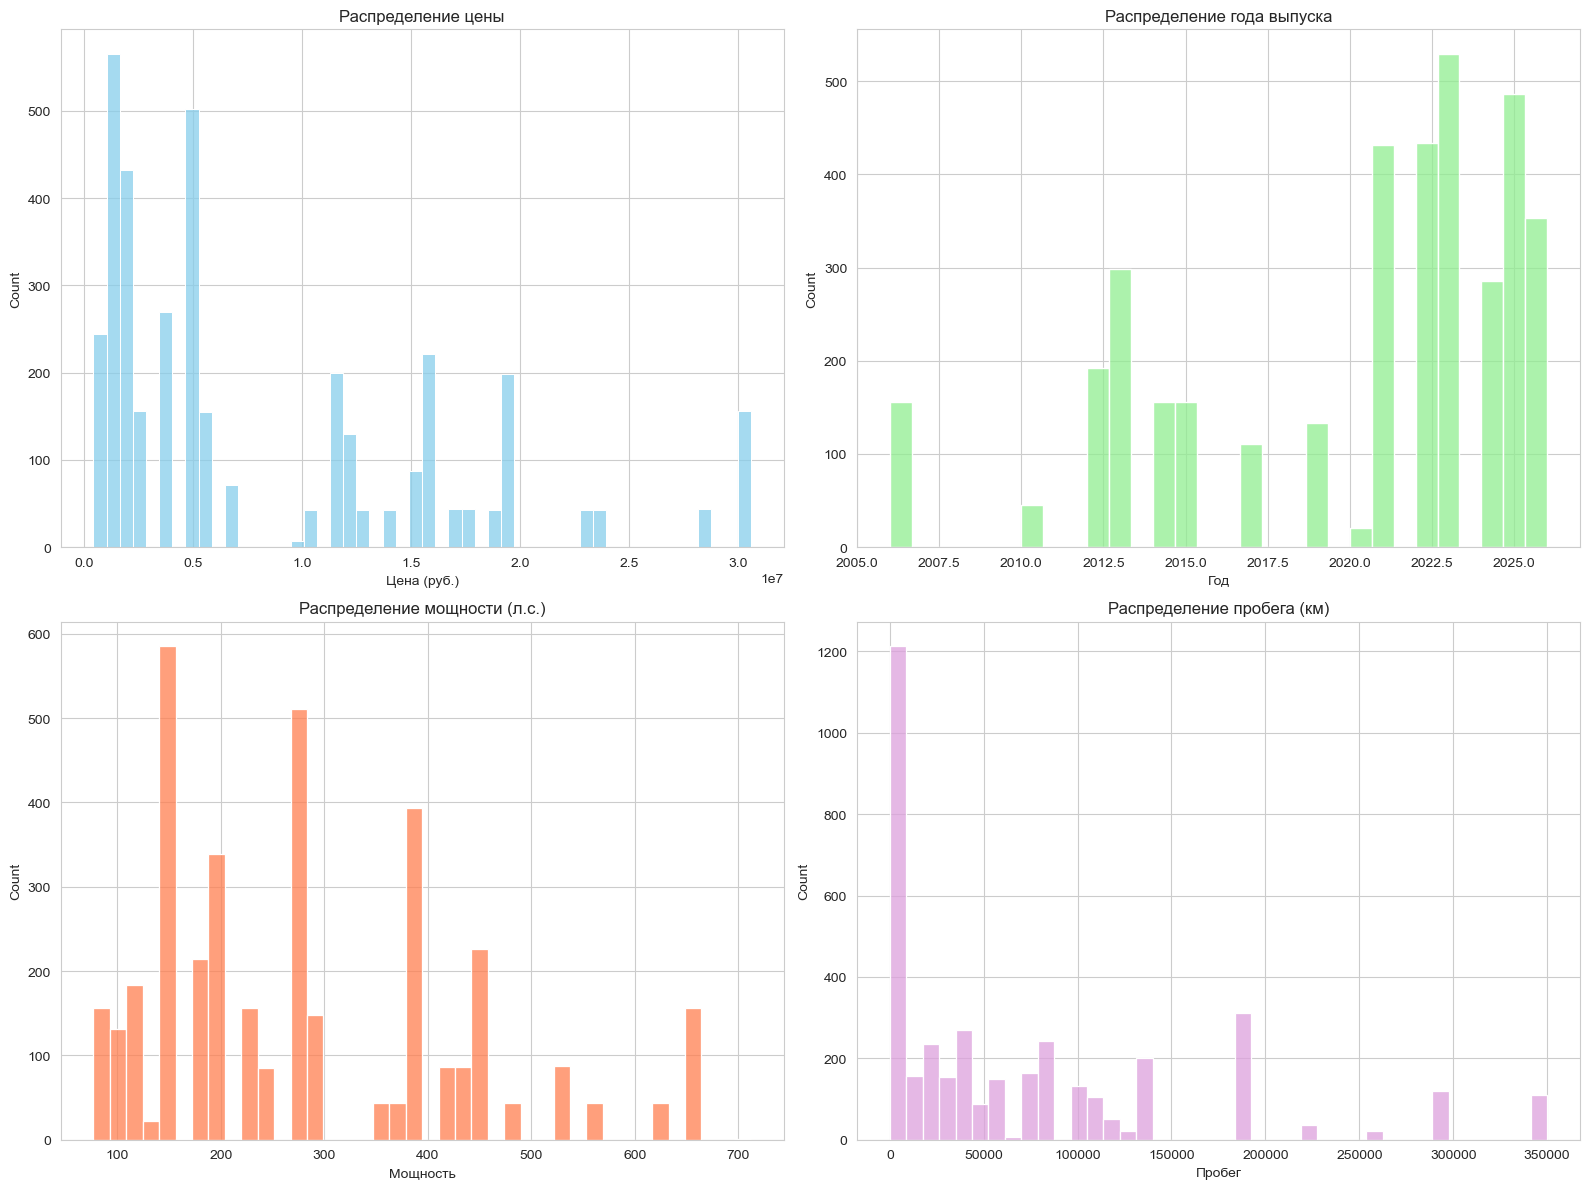

In [28]:
# Графики распределения

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Распределение цены
ax1 = axes[0, 0]
sns.histplot(df_clean_ver2['цена'].dropna(), bins=50, ax=ax1, color='skyblue')
ax1.set_title('Распределение цены')
ax1.set_xlabel('Цена (руб.)')

# Распределение года
ax2 = axes[0, 1]
sns.histplot(df_clean_ver2['год'].dropna(), bins=30, ax=ax2, color='lightgreen')
ax2.set_title('Распределение года выпуска')
ax2.set_xlabel('Год')

# Распределение мощности
ax3 = axes[1, 0]
sns.histplot(df_clean_ver2['мощность'].dropna(), bins=40, ax=ax3, color='coral')
ax3.set_title('Распределение мощности (л.с.)')
ax3.set_xlabel('Мощность')

# Распределение пробега
ax4 = axes[1, 1]
# Преобразуем пробег в числа и удаляем пропуски
mileage = pd.to_numeric(df_clean_ver2['пробег'], errors='coerce').dropna()
sns.histplot(mileage, bins=40, ax=ax4, color='plum')
ax4.set_title('Распределение пробега (км)')
ax4.set_xlabel('Пробег')

plt.tight_layout()
plt.show()

In [29]:
"""
Анализ графиков

1. Распределение цены
Большинство авто находится в диапозоне 0-3 млн рублей
Далее идет плавный спад
Есть выбросы (дорогие авто), но их мало
Вывод: рынок сконцентрирован на бюджетных и среднебюджетных авто, дорогие авто - редкость

2. Распределение года выпуска
Основная масса автомобилей — 2018–2024 годов
Пик приходится на 2022–2024 годы
Авто старше 2015 — очень мало
Вывод: рынок поддержанных авто в основном 3-6 лет

3. Распределение мощности
Два пика:
150–200 л.с. (массовый сегмент)
250–400 л.с. (бизнес-класс и кроссоверы)
Есть авто с мощностью 500–700 л.с. (спорт, премиум)
Вывод: основная масса — средне-мощные авто (до 250 л.с.)

4. Распределение пробега
Огромный пик при пробеге = 0 (это новые авто)
Основной пробег — 0–50 000 км
Дальше резкий спад
Вывод: очень много новых и малопробежных авто, авто с пробегом больше 100тыс км редкость
"""

'\nАнализ графиков\n\n1. Распределение цены\nБольшинство авто находится в диапозоне 0-3 млн рублей\nДалее идет плавный спад\nЕсть выбросы (дорогие авто), но их мало\nВывод: рынок сконцентрирован на бюджетных и среднебюджетных авто, дорогие авто - редкость\n\n2. Распределение года выпуска\nОсновная масса автомобилей — 2018–2024 годов\nПик приходится на 2022–2024 годы\nАвто старше 2015 — очень мало\nВывод: рынок поддержанных авто в основном 3-6 лет\n\n3. Распределение мощности\nДва пика:\n150–200 л.с. (массовый сегмент)\n250–400 л.с. (бизнес-класс и кроссоверы)\nЕсть авто с мощностью 500–700 л.с. (спорт, премиум)\nВывод: основная масса — средне-мощные авто (до 250 л.с.)\n\n4. Распределение пробега\nОгромный пик при пробеге = 0 (это новые авто)\nОсновной пробег — 0–50 000 км\nДальше резкий спад\nВывод: очень много новых и малопробежных авто, авто с пробегом больше 100тыс км редкость\n'

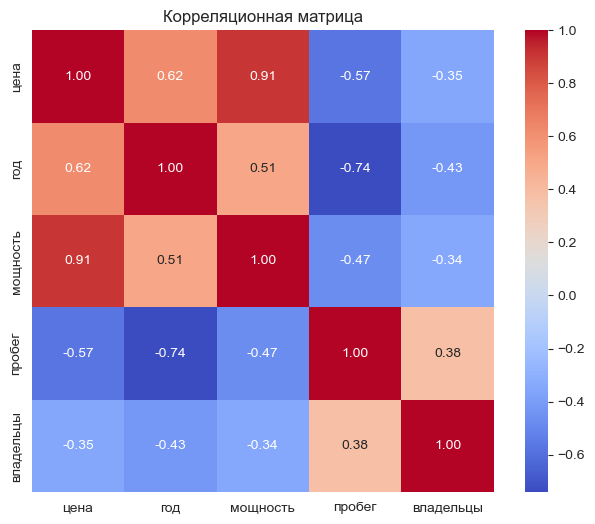


Корреляция с ценой:
цена         1.000000
мощность     0.911103
год          0.622451
владельцы   -0.347538
пробег      -0.573775
Name: цена, dtype: float64


In [30]:
# Корреляционная матрица

# числовые колонки
numeric_cols = ['цена', 'год', 'мощность', 'пробег', 'владельцы']
df_corr = df_clean_ver2[numeric_cols].dropna()

corr_matrix = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Корреляционная матрица')
plt.show()

print("\nКорреляция с ценой:")
print(corr_matrix['цена'].sort_values(ascending=False))

In [31]:
"""
Цена автомобиля сильнее всего зависит от мощности и года выпуска, а также отрицательно связана с пробегом.
Это логично и соответствует ожиданиям: машины с большим пробегом дешевеют, а мощные и новые — дорожают.
Количество владельцев влияет на цену меньше всего — этот фактор можно считать второстепенным при оценке стоимости авто.

"""

'\nЦена автомобиля сильнее всего зависит от мощности и года выпуска, а также отрицательно связана с пробегом.\nЭто логично и соответствует ожиданиям: машины с большим пробегом дешевеют, а мощные и новые — дорожают.\nКоличество владельцев влияет на цену меньше всего — этот фактор можно считать второстепенным при оценке стоимости авто.\n\n'

In [32]:
# топ-10 марок по цене и количеству

print("ТОП-10 МАРОК ПО КОЛИЧЕСТВУ")
print(df_clean_ver2['марка_модель'].value_counts().head(10))

print()
print("ТОП-10 МАРОК ПО СРЕДНЕЙ ЦЕНЕ")

avg_price = df_clean_ver2.groupby('марка_модель')['цена'].mean().sort_values(ascending=False).head(10)
print(avg_price)

ТОП-10 МАРОК ПО КОЛИЧЕСТВУ
марка_модель
БМВ Х7                304
Мерседес GLS-класс    222
БМВ 5 серии           207
Лексус ЛХ 700х        199
Мерседес V-Класс      163
Зикр 9Х               156
Porsche 911           156
Хендай Солярис        156
Фиат Добло            156
Ниссан Патфайндер     156
Name: count, dtype: int64

ТОП-10 МАРОК ПО СРЕДНЕЙ ЦЕНЕ
марка_модель
Porsche 911           3.059400e+07
БМВ Х5                2.349000e+07
БМВ ХМ                2.299000e+07
Лексус ЛХ 700х        1.928608e+07
Кадиллак Эскалейд     1.899000e+07
Мерседес GLS-класс    1.846748e+07
RAM 1500              1.649000e+07
Тойота Секвойя        1.514000e+07
Мерседес S-Класс      1.499000e+07
БМВ Х7                1.393905e+07
Name: цена, dtype: float64


In [33]:
"""
Если посмотреть на график распределения цен, видно, что большинство машин в выборке стоят до 3 миллионов рублей. 
Это бюджетный и среднебюджетный сегмент — именно таких авто на рынке больше всего.
Но если посмотреть на самые популярные марки по количеству объявлений, то в топе оказываются BMW и Mercedes. 
У BMW и Mercedes очень широкий модельный ряд: есть и доступные модели, и люксовые. 
Их много продаётся, поэтому они и попадают в топ по количеству.
А вот средняя цена марки сильно завышается за счёт дорогих моделей, таких как Porsche 911 или BMW X5. 
Сами по себе такие машины встречаются нечасто, но именно они «тянут» среднюю цену вверх.
Получается, что рынок двойной:
Массовый сегмент даёт основное количество машин, но они недорогие;
Премиальный сегмент даёт мало машин, но они очень дорогие.

"""

'\nЕсли посмотреть на график распределения цен, видно, что большинство машин в выборке стоят до 3 миллионов рублей. \nЭто бюджетный и среднебюджетный сегмент — именно таких авто на рынке больше всего.\nНо если посмотреть на самые популярные марки по количеству объявлений, то в топе оказываются BMW и Mercedes. \nУ BMW и Mercedes очень широкий модельный ряд: есть и доступные модели, и люксовые. \nИх много продаётся, поэтому они и попадают в топ по количеству.\nА вот средняя цена марки сильно завышается за счёт дорогих моделей, таких как Porsche 911 или BMW X5. \nСами по себе такие машины встречаются нечасто, но именно они «тянут» среднюю цену вверх.\nПолучается, что рынок двойной:\nМассовый сегмент даёт основное количество машин, но они недорогие;\nПремиальный сегмент даёт мало машин, но они очень дорогие.\n\n'

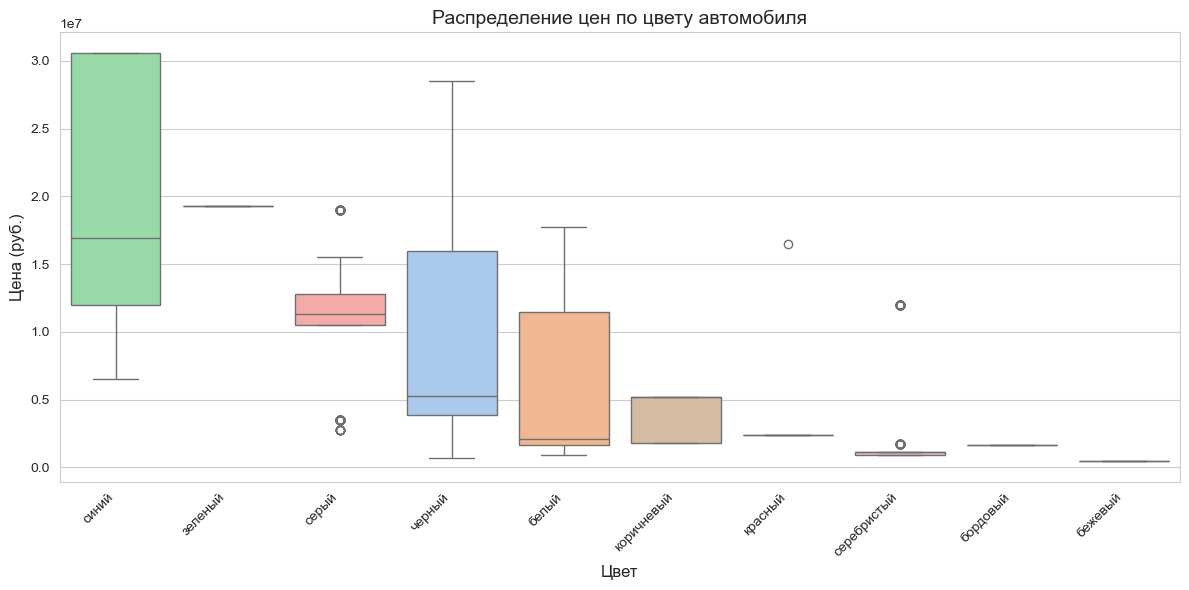


СРЕДНЯЯ ЦЕНА ПО ЦВЕТУ

  синий             20,658,806 руб.
  зеленый           19,285,000 руб.
  серый             11,137,763 руб.
  черный             8,489,190 руб.
  белый              5,862,919 руб.
  коричневый         4,217,973 руб.
  красный            2,484,000 руб.
  серебристый        2,305,908 руб.
  бордовый           1,650,000 руб.
  бежевый              439,000 руб.

Самый дорогой цвет: синий (20,658,806 руб.)
Самый дешёвый цвет: бежевый (439,000 руб.)


In [34]:
# Настройка формата чисел
pd.set_option('display.float_format', '{:,.0f}'.format)

# Сортируем цвета по средней цене
color_order = df_clean_ver2.groupby('цвет')['цена'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean_ver2, x='цвет', y='цена', order=color_order, 
            hue='цвет', palette='pastel', legend=False)
plt.title('Распределение цен по цвету автомобиля', fontsize=14)
plt.xlabel('Цвет', fontsize=12)
plt.ylabel('Цена (руб.)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Вывод средней цены
print()
print("СРЕДНЯЯ ЦЕНА ПО ЦВЕТУ")
print()

avg_price = df_clean_ver2.groupby('цвет')['цена'].mean().sort_values(ascending=False)

for color, price in avg_price.items():
    print(f"  {color:12} {price:>15,.0f} руб.")

print()
print(f"Самый дорогой цвет: {avg_price.index[0]} ({avg_price.iloc[0]:,.0f} руб.)")
print(f"Самый дешёвый цвет: {avg_price.index[-1]} ({avg_price.iloc[-1]:,.0f} руб.)")

In [35]:
"""
Цвет автомобиля коррелирует с его ценой, но это скорее не причина, а следствие:
Дорогие цвета (синий, зелёный, серый) — это цвета премиальных марок (BMW, Mercedes, Porsche). 
Их выбирают для дорогих автомобилей.

Самые популярные цвета (чёрный, белый) — находятся в среднем ценовом сегменте. 
Это универсальные цвета, которые встречаются у всех марок.

Дешёвые цвета (бордовый, бежевый) — чаще встречаются у бюджетных и старых автомобилей.

Самый дорогой цвет — синий, а самый дешёвый — бежевый.

"""

'\nЦвет автомобиля коррелирует с его ценой, но это скорее не причина, а следствие:\nДорогие цвета (синий, зелёный, серый) — это цвета премиальных марок (BMW, Mercedes, Porsche). \nИх выбирают для дорогих автомобилей.\n\nСамые популярные цвета (чёрный, белый) — находятся в среднем ценовом сегменте. \nЭто универсальные цвета, которые встречаются у всех марок.\n\nДешёвые цвета (бордовый, бежевый) — чаще встречаются у бюджетных и старых автомобилей.\n\nСамый дорогой цвет — синий, а самый дешёвый — бежевый.\n\n'

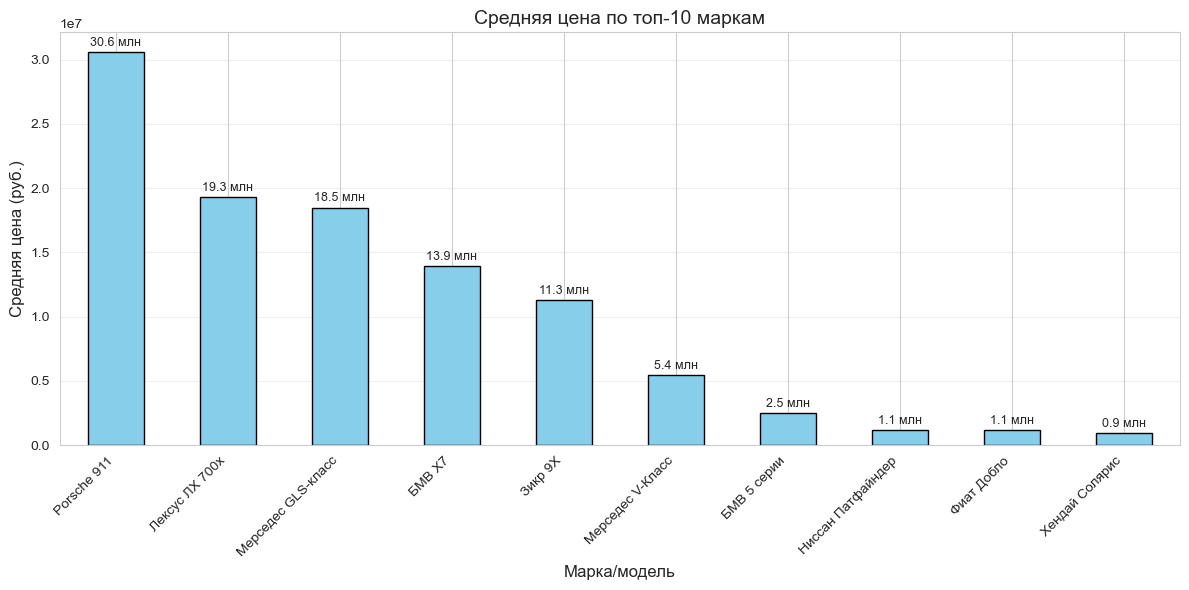

Средняя цена по маркам:
  Porsche 911: 30.59 млн руб.
  Лексус ЛХ 700х: 19.29 млн руб.
  Мерседес GLS-класс: 18.47 млн руб.
  БМВ Х7: 13.94 млн руб.
  Зикр 9Х: 11.30 млн руб.
  Мерседес V-Класс: 5.45 млн руб.
  БМВ 5 серии: 2.47 млн руб.
  Ниссан Патфайндер: 1.15 млн руб.
  Фиат Добло: 1.15 млн руб.
  Хендай Солярис: 0.93 млн руб.


In [36]:
# Средняя цена по маркам

# топ-10 марок по количеству
top_brands = df_clean_ver2['марка_модель'].value_counts().head(10).index
df_top = df_clean_ver2[df_clean_ver2['марка_модель'].isin(top_brands)]

# Средняя цена по каждой марке
avg_price = df_top.groupby('марка_модель')['цена'].mean().sort_values(ascending=False)

# Столбчатая диаграмма
plt.figure(figsize=(12, 6))
avg_price.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Средняя цена по топ-10 маркам', fontsize=14)
plt.xlabel('Марка/модель', fontsize=12)
plt.ylabel('Средняя цена (руб.)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Значения над столбцами
for i, price in enumerate(avg_price):
    plt.text(i, price + 500000, f'{price/1_000_000:.1f} млн', 
             ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Средняя цена по маркам:")
for brand, price in avg_price.items():
    print(f"  {brand}: {price/1_000_000:.2f} млн руб.")

In [37]:
"""
Самой дорогой маркой в выборке оказался Porsche 911 — его средняя цена составляет почти 30 миллионов рублей. 
Это логично, так как речь идёт о спортивном автомобиле премиум-сегмента.
Второе и третье место Lexus LX 700h и Mercedes GLS-класс — их средняя цена в районе 19 и 18 миллионов рублей. 
Это тоже премиальные модели, но уже среди внедорожников.
BMW X7 и Zeekr 9X оказались в середине списка — около 14 и 11 миллионов рублей.
Самые доступные марки — Hyundai Solaris, Fiat Doblo и Nissan Pathfinder — их средняя цена не превышает 1,2 миллиона рублей. 

"""

'\nСамой дорогой маркой в выборке оказался Porsche 911 — его средняя цена составляет почти 30 миллионов рублей. \nЭто логично, так как речь идёт о спортивном автомобиле премиум-сегмента.\nВторое и третье место Lexus LX 700h и Mercedes GLS-класс — их средняя цена в районе 19 и 18 миллионов рублей. \nЭто тоже премиальные модели, но уже среди внедорожников.\nBMW X7 и Zeekr 9X оказались в середине списка — около 14 и 11 миллионов рублей.\nСамые доступные марки — Hyundai Solaris, Fiat Doblo и Nissan Pathfinder — их средняя цена не превышает 1,2 миллиона рублей. \n\n'

In [38]:
# Объединение АКПП и автомат

df_clean_ver3 = df_clean_ver2.copy()

# Объединяем АКПП и автомат
df_clean_ver3['коробка'] = df_clean_ver3['коробка'].replace({
    'автомат': 'АКПП'
})

# Проверка
print("Распределение после объединения:")
print(df_clean_ver3['коробка'].value_counts())

Распределение после объединения:
коробка
АКПП        2893
механика     420
робот        416
вариатор      57
Name: count, dtype: int64


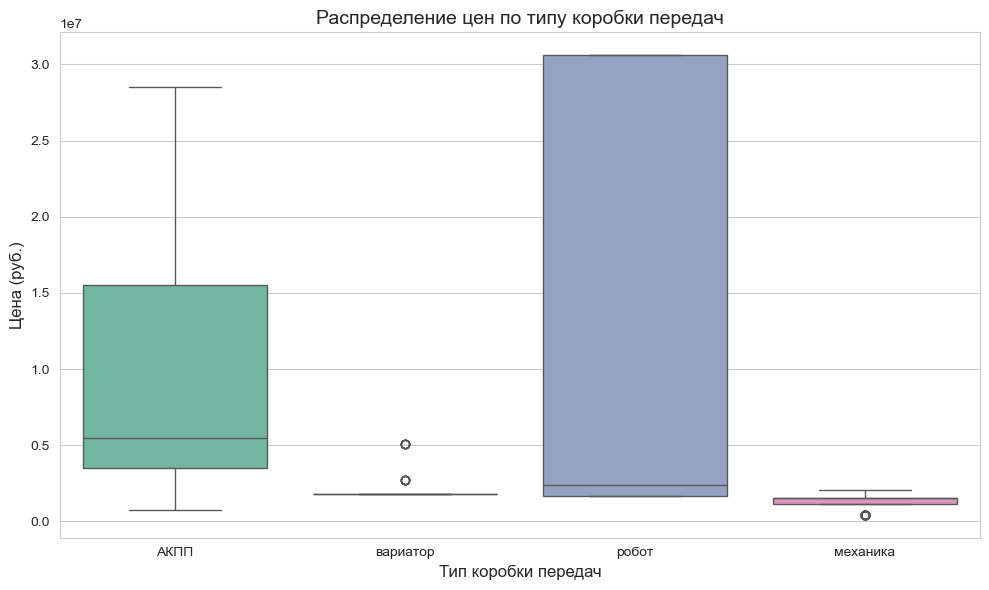

In [39]:
# Распределение цены по коробке передач

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean_ver3, x='коробка', y='цена', 
            hue='коробка', palette='Set2', legend=False)
plt.title('Распределение цен по типу коробки передач', fontsize=14)
plt.xlabel('Тип коробки передач', fontsize=12)
plt.ylabel('Цена (руб.)', fontsize=12)
plt.tight_layout()
plt.show()

In [40]:
"""
Самые дорогие автомобили в выборке — с автоматической коробкой передач (АКПП). 
Их медианная цена составляет около 1.5 млн рублей, а максимальная достигает 14 млн рублей.
На втором месте — роботизированная коробка (робот) с медианной ценой около 3.1 млн рублей. 
Это связано с тем, что роботы чаще встречаются на современных автомобилях среднего и бизнес-класса.
Механика и вариатор находятся в бюджетном сегменте — их медианная цена не превышает 50-100 тыс. рублей. 
Это логично, так как такие коробки чаще устанавливаются на недорогие и старые автомобили.
Важно отметить, что у АКПП самый большой разброс цен: от 0.5 до 14 млн рублей. 
Это объясняется тем, что АКПП устанавливается как на бюджетные, так и на премиальные автомобили.

"""

'\nСамые дорогие автомобили в выборке — с автоматической коробкой передач (АКПП). \nИх медианная цена составляет около 1.5 млн рублей, а максимальная достигает 14 млн рублей.\nНа втором месте — роботизированная коробка (робот) с медианной ценой около 3.1 млн рублей. \nЭто связано с тем, что роботы чаще встречаются на современных автомобилях среднего и бизнес-класса.\nМеханика и вариатор находятся в бюджетном сегменте — их медианная цена не превышает 50-100 тыс. рублей. \nЭто логично, так как такие коробки чаще устанавливаются на недорогие и старые автомобили.\nВажно отметить, что у АКПП самый большой разброс цен: от 0.5 до 14 млн рублей. \nЭто объясняется тем, что АКПП устанавливается как на бюджетные, так и на премиальные автомобили.\n\n'

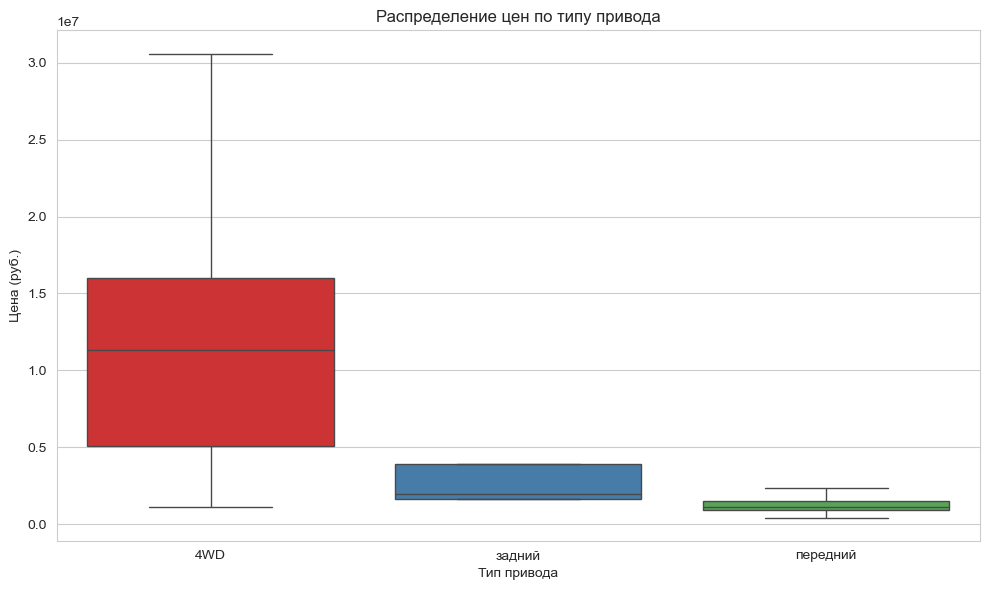

In [41]:
# Распределение цены по приводу
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean_ver3, x='привод', y='цена', hue='привод', palette='Set1', legend=False)
plt.title('Распределение цен по типу привода')
plt.xlabel('Тип привода')
plt.ylabel('Цена (руб.)')
plt.tight_layout()
plt.show()


In [42]:
"""
Полный привод (4WD) — самый дорогой, передний привод — самый дешёвый. 
Это логично, так как полный привод устанавливается на премиальные внедорожники, а передний — на бюджетные автомобили. 
Задний привод занимает промежуточное положение.

"""

'\nПолный привод (4WD) — самый дорогой, передний привод — самый дешёвый. \nЭто логично, так как полный привод устанавливается на премиальные внедорожники, а передний — на бюджетные автомобили. \nЗадний привод занимает промежуточное положение.\n\n'

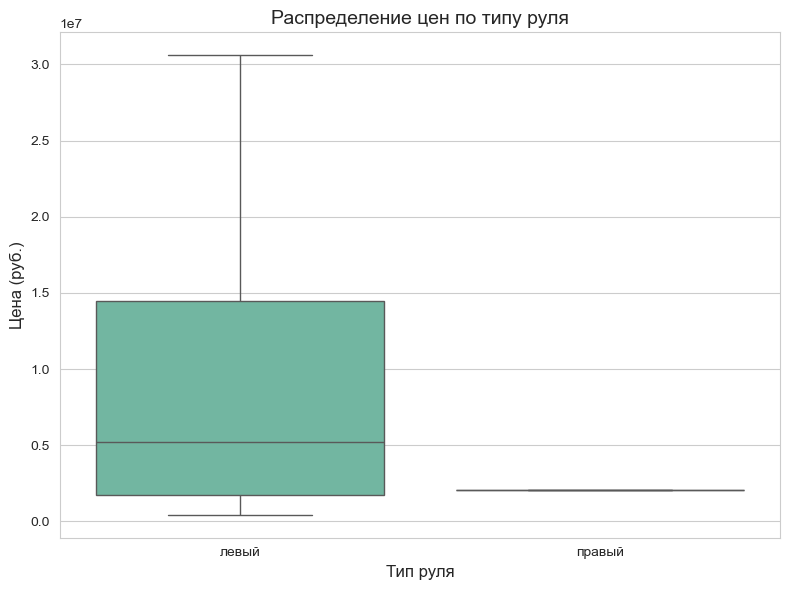


СРЕДНЯЯ ЦЕНА ПО ТИПУ РУЛЯ

  левый            8,511,179 руб.
  правый           2,080,000 руб.

КОЛИЧЕСТВО МАШИН ПО ТИПУ РУЛЯ

руль
левый     3700
правый      86
Name: count, dtype: int64


In [43]:
# Распределение цены по типу руля

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean_ver3, x='руль', y='цена', 
            hue='руль', palette='Set2', legend=False)
plt.title('Распределение цен по типу руля', fontsize=14)
plt.xlabel('Тип руля', fontsize=12)
plt.ylabel('Цена (руб.)', fontsize=12)
plt.tight_layout()
plt.show()

# Вывод средней цены
print()
print("СРЕДНЯЯ ЦЕНА ПО ТИПУ РУЛЯ")
print()

avg_price = df_clean_ver3.groupby('руль')['цена'].mean().sort_values(ascending=False)
for wheel, price in avg_price.items():
    print(f"  {wheel:10} {price:>15,.0f} руб.")

# Количество машин по типу руля
print()
print("КОЛИЧЕСТВО МАШИН ПО ТИПУ РУЛЯ")
print()
print(df_clean_ver3['руль'].value_counts())

In [44]:
"""
Автомобили с левым рулём стоят дороже (медиана ~1.4 млн руб.), чем с правым (медиана ~500 тыс. руб.). 
Разница в цене — около 900 тыс. рублей.
Это логично: в России левый руль — стандарт, он удобнее и безопаснее. 
Праворульные авто менее популярны, их меньше на рынке, и они стоят дешевле.

"""

'\nАвтомобили с левым рулём стоят дороже (медиана ~1.4 млн руб.), чем с правым (медиана ~500 тыс. руб.). \nРазница в цене — около 900 тыс. рублей.\nЭто логично: в России левый руль — стандарт, он удобнее и безопаснее. \nПраворульные авто менее популярны, их меньше на рынке, и они стоят дешевле.\n\n'

In [45]:
# Анализ выбросов

df_outliers = df_clean_ver3.copy()

# Определение порога для выбросов (1% и 5% от общего количества)
n = len(df_outliers)
top_1_pct = int(n * 0.01)  # 1% самых дорогих
top_5_pct = int(n * 0.05)  # 5% самых дорогих
bottom_1_pct = int(n * 0.01)  # 1% самых дешевых
bottom_5_pct = int(n * 0.05)  # 5% самых дешевых

# Сортировка по цене
df_sorted_by_price = df_outliers.sort_values('цена', ascending=False)

# Топ 1% и 5% самых дорогих
top_1 = df_sorted_by_price.head(top_1_pct)
top_5 = df_sorted_by_price.head(top_5_pct)

# Топ 1% и 5% самых дешевых
bottom_1 = df_sorted_by_price.tail(bottom_1_pct)
bottom_5 = df_sorted_by_price.tail(bottom_5_pct)

print(f"Всего записей: {n}")
print(f"Топ 1% дорогих: {len(top_1)} машин, порог цены: {top_1['цена'].min():,.0f} руб.")
print(f"Топ 5% дорогих: {len(top_5)} машин, порог цены: {top_5['цена'].min():,.0f} руб.")
print(f"Топ 1% дешевых: {len(bottom_1)} машин, порог цены: {bottom_1['цена'].max():,.0f} руб.")
print(f"Топ 5% дешевых: {len(bottom_5)} машин, порог цены: {bottom_5['цена'].max():,.0f} руб.")

Всего записей: 3786
Топ 1% дорогих: 37 машин, порог цены: 30,594,000 руб.
Топ 5% дорогих: 189 машин, порог цены: 28,490,000 руб.
Топ 1% дешевых: 37 машин, порог цены: 439,000 руб.
Топ 5% дешевых: 189 машин, порог цены: 930,000 руб.


In [46]:
# Анализ дорогих выбросов
print()
print("Анализ ТОП 1% автомобилей")
print()
print("\nТоп-5 марок в топ 1%:")
print(top_1['марка_модель'].value_counts().head(10))

print("\nСтатистика по топ 1%:")
print(top_1[['цена', 'год', 'мощность', 'пробег']].describe())

print("\nПримеры самых дорогих машин (первые 5):")
print(top_1[['марка_модель', 'цена', 'год', 'мощность', 'пробег']].head(5))

print()
print("Анализ ТОП 5% автомобилей")
print()
print("\nТоп-10 марок в топ 5%:")
print(top_5['марка_модель'].value_counts().head(10))


Анализ ТОП 1% автомобилей


Топ-5 марок в топ 1%:
марка_модель
Porsche 911    37
Name: count, dtype: int64

Статистика по топ 1%:
            цена   год  мощность  пробег
count         37    37        37      37
mean  30,594,000 2,023       650   5,455
std            0     0         0       0
min   30,594,000 2,023       650   5,455
25%   30,594,000 2,023       650   5,455
50%   30,594,000 2,023       650   5,455
75%   30,594,000 2,023       650   5,455
max   30,594,000 2,023       650   5,455

Примеры самых дорогих машин (первые 5):
     марка_модель      цена   год  мощность  пробег
4893  Porsche 911  30594000 2,023       650    5455
4918  Porsche 911  30594000 2,023       650    5455
4843  Porsche 911  30594000 2,023       650    5455
1369  Porsche 911  30594000 2,023       650    5455
1344  Porsche 911  30594000 2,023       650    5455

Анализ ТОП 5% автомобилей


Топ-10 марок в топ 5%:
марка_модель
Porsche 911           156
Мерседес GLS-класс     33
Name: count, dtype: int64


In [49]:
# Анализ дешевых выбросов

print()
print("Анализ самых дешевых автомобилей (Нижние 1%)")
print()
print("\nТоп-5 марок в нижних 1%:")
print(bottom_1['марка_модель'].value_counts().head(10))

print("\nСтатистика по нижним 1%:")
print(bottom_1[['цена', 'год', 'мощность', 'пробег']].describe())

print("\nПримеры самых дешевых машин (первые 5):")
print(bottom_1[['марка_модель', 'цена', 'год', 'мощность', 'пробег']].head(5))

print()
print("Анализ самых дешевых автомобилей(НИЖНИЕ 5%)")
print()
print()
print(bottom_5['марка_модель'].value_counts().head(10))


Анализ самых дешевых автомобилей (Нижние 1%)


Топ-5 марок в нижних 1%:
марка_модель
Киа Рио    37
Name: count, dtype: int64

Статистика по нижним 1%:
         цена   год  мощность  пробег
count      37    37        37      37
mean  439,000 2,010        95 139,000
std         0     0         0       0
min   439,000 2,010        95 139,000
25%   439,000 2,010        95 139,000
50%   439,000 2,010        95 139,000
75%   439,000 2,010        95 139,000
max   439,000 2,010        95 139,000

Примеры самых дешевых машин (первые 5):
     марка_модель    цена   год  мощность  пробег
2047      Киа Рио  439000 2,010        95  139000
2072      Киа Рио  439000 2,010        95  139000
1271      Киа Рио  439000 2,010        95  139000
1296      Киа Рио  439000 2,010        95  139000
1096      Киа Рио  439000 2,010        95  139000

Анализ самых дешевых автомобилей(НИЖНИЕ 5%)


марка_модель
Хендай Солярис      105
Киа Рио              45
Опель Астра GTC      22
Фольксваген Поло     17
Name: cou

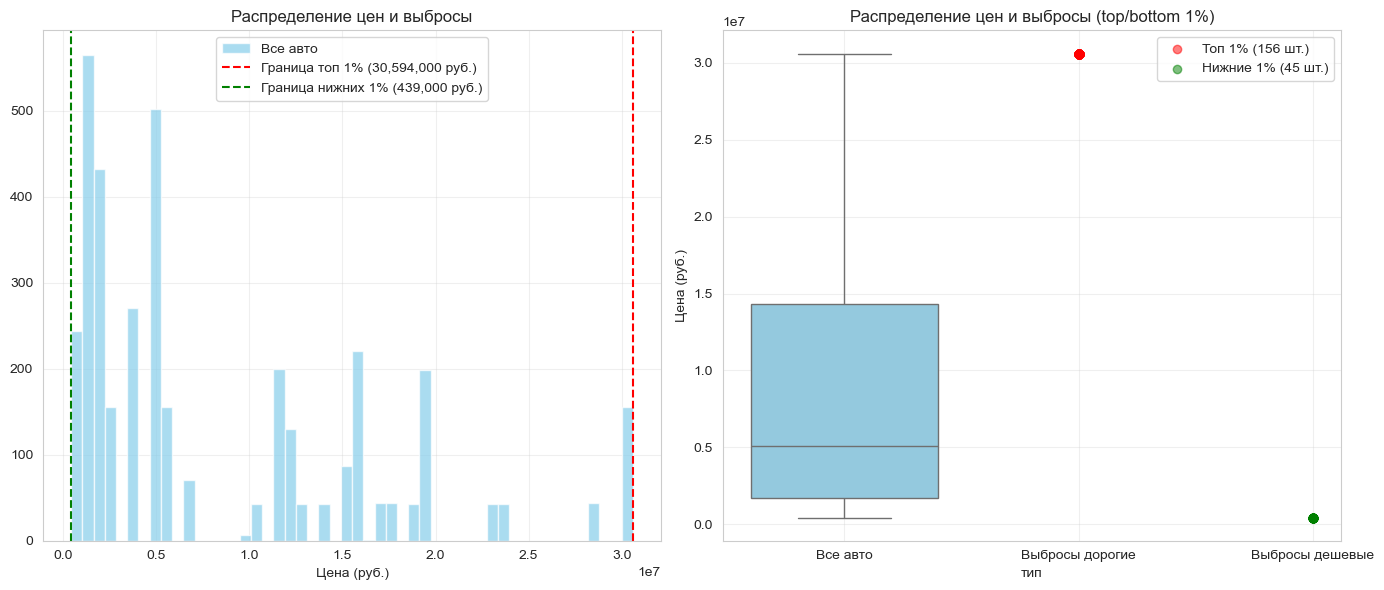

In [50]:
# График для наглядного представления выбросов
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Цена с выделением выбросов
ax1 = axes[0]
ax1.hist(df_outliers['цена'], bins=50, alpha=0.7, label='Все авто', color='skyblue')
ax1.axvline(top_1['цена'].min(), color='red', linestyle='--', label=f'Граница топ 1% ({top_1["цена"].min():,.0f} руб.)')
ax1.axvline(bottom_1['цена'].max(), color='green', linestyle='--', label=f'Граница нижних 1% ({bottom_1["цена"].max():,.0f} руб.)')
ax1.set_title('Распределение цен и выбросы')
ax1.set_xlabel('Цена (руб.)')
ax1.legend()
ax1.grid(alpha=0.3)

# График 2: Боксплот для наглядности
ax2 = axes[1]
# Создаем отдельный датафрейм для боксплота
df_boxplot = df_outliers.copy()
# Добавляем колонку-категорию для раскраски
df_boxplot['тип'] = 'Все авто'
# Отдельно выделяем выбросы
df_outliers_high = df_outliers[df_outliers['цена'] >= top_1['цена'].min()]
df_outliers_low = df_outliers[df_outliers['цена'] <= bottom_1['цена'].max()]

sns.boxplot(data=df_boxplot, x='тип', y='цена', ax=ax2, color='skyblue')
ax2.scatter(['Выбросы дорогие'] * len(df_outliers_high), df_outliers_high['цена'], 
            color='red', alpha=0.5, label=f'Топ 1% ({len(df_outliers_high)} шт.)')
ax2.scatter(['Выбросы дешевые'] * len(df_outliers_low), df_outliers_low['цена'], 
            color='green', alpha=0.5, label=f'Нижние 1% ({len(df_outliers_low)} шт.)')
ax2.set_title('Распределение цен и выбросы (top/bottom 1%)')
ax2.set_ylabel('Цена (руб.)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# Добавляем 'цена' в группировку
grouped = df.groupby(['марка_модель', 'год', 'пробег', 'мощность', 'цена']).size().reset_index(name='count')

# Смотрим на комбинации, где count > 1
duplicates_combos = grouped[grouped['count'] > 1].sort_values('count', ascending=False)
print(duplicates_combos.head(10))

         марка_модель   год   пробег  мощность      цена  count
0         Porsche 911 2,023    5 455       650  30594000    156
5         БМВ 5 серии 2,013  190 474       184   2000000    156
29   Мерседес V-Класс 2,015   79 650       190   5245000    156
45         Фиат Добло 2,014   71 100        77   1150000    156
48     Хендай Солярис 2,012  131 500       123    930000    156
33  Ниссан Патфайндер 2,006  185 985       269   1150000    156
17            Зикр 9Х 2,025    8 000       279  11299000    156
21     Лексус ЛХ 700х 2,024    6 000       457  19285000    156
23      Лексус НХ 350 2,022   33 000       279   5500000    155
4         БМВ 3 серии 2,023   43 700       156   3900000    149


In [54]:
# 1. Считаем количество уникальных комбинаций (с учетом цены)
df_unique = df.drop_duplicates(subset=['марка_модель', 'год', 'пробег', 'мощность', 'цена'])

# 2. Сколько всего уникальных записей осталось?
print(f"Всего уникальных записей (моделей): {len(df_unique)}")

# 3. Выведем ВСЕ уникальные записи, чтобы убедиться, что дубликатов среди них нет
print(df_unique[['марка_модель', 'год', 'пробег', 'мощность', 'цена']].sort_values('цена', ascending=False))

# 4. Проверка: есть ли среди оставшихся записей те, у которых count > 1?
# (Это исключит ситуацию, когда остались две РАЗНЫЕ машины с одинаковыми характеристиками)
check_dups = df_unique.groupby(['марка_модель', 'год', 'пробег', 'мощность', 'цена']).size().reset_index(name='count')
print(f"\nКоличество оставшихся строк с count > 1: {len(check_dups[check_dups['count'] > 1])}")

Всего уникальных записей (моделей): 67
            марка_модель   год   пробег  мощность      цена
1094         Porsche 911 2,023    5 455       650  30594000
0     Мерседес GLS-класс 2,026       81       557  28490000
21                БМВ Х5 2,026      491       625  23490000
20                БМВ ХМ 2,025      193       489  22990000
15        Лексус ЛХ 700х 2,025      747       415  19290000
...                  ...   ...      ...       ...       ...
1106    Фольксваген Поло 2,020  258 000       110    930000
1985                 NaN   NaN      NaN       NaN    799000
1101     Опель Астра GTC 2,013  124 000       140    720000
1096             Киа Рио 2,010  139 000        95    439000
1989                 NaN   NaN      NaN       NaN     97000

[67 rows x 5 columns]

Количество оставшихся строк с count > 1: 0
